##**Лаба 3. Анализ главных компонент**




##Установка необходимых библиотек

In [2]:
# Импортируем необходимые модули
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from google.colab import drive

##Загрузка данных

In [11]:
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/kc_house_data.csv'

# Загружаем данные в DataFrame
kc_house_data = pd.read_csv(file_path)

# Просмотр первых строк данных
kc_house_data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


##Анализ данных


In [4]:
# Получаем информацию о данных
data.info()

# Проверяем наличие пропусков
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


##Анализ главных компонент

Вклад каждого компонента в объяснение вариации:
[0.37033616 0.19414099 0.14364649 0.12066885 0.08415502 0.05609468
 0.0309578 ]


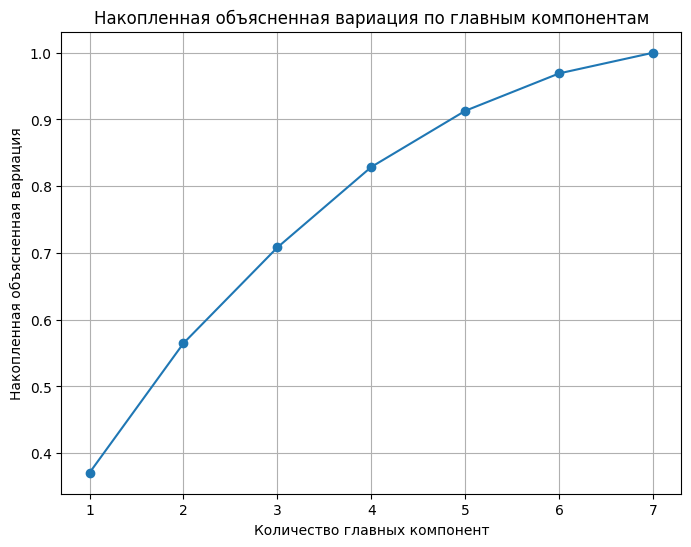

Компоненты PCA:
[[ 0.55581895  0.11047092  0.43146012  0.55104352  0.34998781  0.12075869
   0.22799241]
 [-0.02577628  0.11677826 -0.19243713 -0.13233207 -0.20744808  0.6874766
   0.64458965]
 [ 0.08983313  0.93030834  0.02925064 -0.05501368 -0.28548055 -0.19643581
  -0.04988097]
 [-0.13710999  0.28082821 -0.5718773   0.06963969  0.74342546  0.10351669
  -0.0839399 ]
 [-0.06969341  0.10164462  0.2774647  -0.03606129 -0.0042921   0.67712771
  -0.66933083]
 [-0.40341592  0.12271809  0.60323332 -0.45239403  0.42494651 -0.07061117
   0.26092065]
 [ 0.70422309 -0.06655488 -0.08963127 -0.68191077  0.14033995  0.00162718
  -0.08310409]]


In [14]:
# Выбираем признаки для анализа
selected_features = ['sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'floors', 'waterfront', 'view']

# Извлекаем данные по этим признакам
data_selected = kc_house_data[selected_features]

# Убираем строки с пропущенными значениями
data_selected = data_selected.dropna()

# Стандартизируем данные
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected)

# Применяем PCA
pca = PCA()
pca.fit(data_scaled)

# Выводим вклад каждого компонента в объяснение вариации
print("Вклад каждого компонента в объяснение вариации:")
print(pca.explained_variance_ratio_)

# Накопленная объясненная вариация
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Строим график накопленной объясненной вариации
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.title('Накопленная объясненная вариация по главным компонентам')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объясненная вариация')
plt.grid(True)
plt.show()

# Выводим главные компоненты для интерпретации
print("Компоненты PCA:")
print(pca.components_)


##Что мы получим:

1. Вклад каждого компонента в объяснение вариации: покажет, сколько вариации в данных объясняется каждым компонентом.

2. График накопленной объясненной вариации: этот график покажет, как изменение числа главных компонент влияет на объяснение вариации в данных.

3. Главные компоненты (PCA components): анализируя компоненты, мы сможем интерпретировать, какие признаки вносят наибольший вклад в главные компоненты. Например, если первый компонент сильно зависит от площади (sqft_living), то можно заключить, что площадь дома имеет наибольшее значение для цены недвижимости.

##Интерпретация:

* Если первая главная компонента сильно зависит от площади жилого помещения и количества этажей, это может свидетельствовать о том, что эти характеристики важны для ценообразования.

* Вторая компонента может быть связана с такими признаками, как наличие водоёма или вид, что также может повысить цену дома.

Этот подход поможет выявить скрытые зависимости и дать интерпретацию главных факторов, которые влияют на цену дома.

##Выполним PCA для двух признаков (например, 'sqft_living' и 'sqft_lot')


Вклад каждого компонента в объяснение вариации для двух признаков (стандартизованные данные):
[0.58641283 0.41358717]


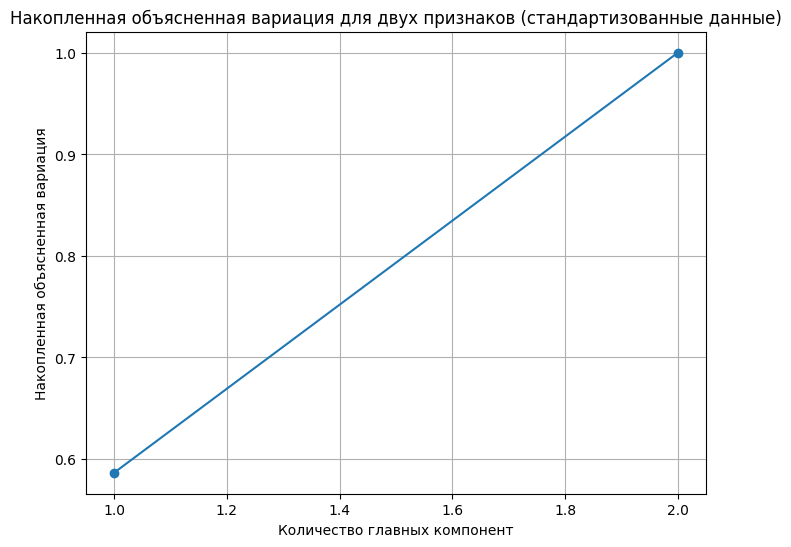

Компоненты PCA:
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In [13]:
selected_features_two = ['sqft_living', 'sqft_lot']

# Извлекаем данные для выбранных признаков
data_selected_two = kc_house_data[selected_features_two]
data_selected_two = data_selected_two.dropna()

# Стандартизируем данные
scaler = StandardScaler()
data_scaled_two = scaler.fit_transform(data_selected_two)

# Применяем PCA для стандартизованных данных
pca_two = PCA()
pca_two.fit(data_scaled_two)

# Выводим вклад каждого компонента в объяснение вариации
print("Вклад каждого компонента в объяснение вариации для двух признаков (стандартизованные данные):")
print(pca_two.explained_variance_ratio_)

# Накопленная объясненная вариация
cumulative_variance_two = np.cumsum(pca_two.explained_variance_ratio_)

# Строим график накопленной объясненной вариации
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance_two) + 1), cumulative_variance_two, marker='o')
plt.title('Накопленная объясненная вариация для двух признаков (стандартизованные данные)')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объясненная вариация')
plt.grid(True)
plt.show()

# Выводим главные компоненты для интерпретации
print("Компоненты PCA:")
print(pca_two.components_)

##Результаты анализа:

1. Вклад главных компонент: Мы получим вклад каждого компонента в общую вариацию. Вероятно, первый компонент будет связан с основными характеристиками (например, площадь жилья и площадь участка), что объяснит основную вариацию данных.

2. Накопленная объясненная вариация: Этот график покажет, как с увеличением числа главных компонент растет объясненная вариация. Мы будем оценивать, сколько вариации объясняется двумя признаками (например, площадь жилого помещения и площадь участка).

3. Интерпретация:

*   Если в первом компоненте будут высокие значения для площади жилья и участка, это будет означать, что оба признака сильно влияют на стоимость недвижимости.
*   Важно отметить, что иногда PCA может показать, что оба признака почти не независимы и их комбинация дает наибольшую объясненную вариацию.



##Сравнение с предыдущим анализом:

В предыдущем пункте мы использовали все признаки для выполнения PCA и выделили главные факторы. При анализе только двух признаков мы можем сравнить, насколько значимый вклад эти два признака вносят в объяснение вариации по сравнению с более широким набором данных.

Если для двух признаков объясненная вариация значительно ниже, чем для всех признаков, это будет означать, что другие параметры, такие как вид или количество этажей, играют важную роль в определении цены.

##PCA для всего набора данных

Вклад каждого компонента в объяснение вариации для всего набора данных:
[0.28377534 0.12075295 0.09378853 0.06931622 0.06146526 0.05032955
 0.04825521 0.04602147 0.04145187 0.03299587 0.03005467 0.02557792
 0.02099668 0.01658877 0.01470855 0.01323098 0.01185964 0.00971089
 0.00911963 0.        ]


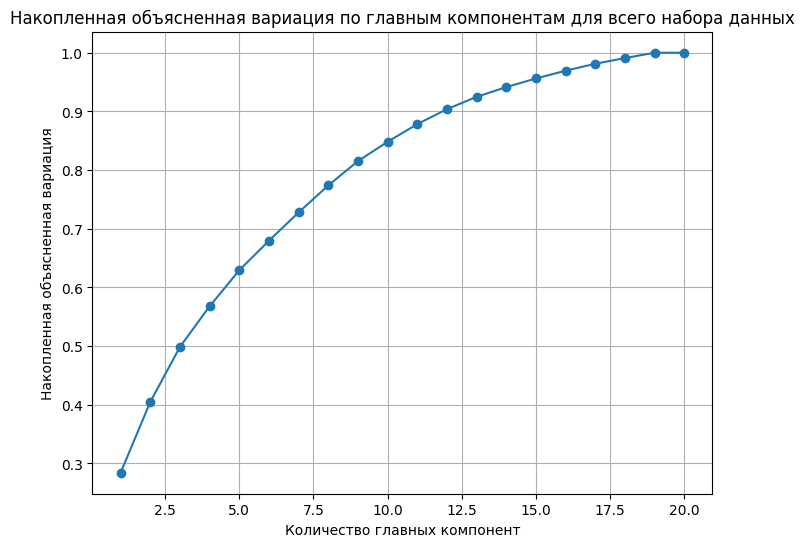

Компоненты PCA для всего набора данных:
[[-4.43916337e-03  2.98973522e-01  2.34528259e-01  3.48623949e-01
   3.87680169e-01  9.40856330e-02  2.18460614e-01  5.99793307e-02
   1.28045742e-01 -6.92764420e-02  3.60311399e-01  3.76879208e-01
   9.93527572e-02  2.16943297e-01  1.27660657e-02 -1.36864190e-01
   1.98111192e-02  1.58578971e-01  3.45318995e-01  9.95494044e-02]
 [ 2.90292629e-03  3.01385226e-01  8.52568060e-02  1.60186667e-02
   1.24142016e-01 -1.36388277e-01 -1.60287943e-01  2.06210028e-01
   3.12890114e-01  2.06900278e-01  4.36799709e-02 -6.68390396e-02
   3.82682921e-01 -3.63955005e-01  1.74150434e-01  3.35375116e-01
   2.54115748e-01 -3.79761141e-01  2.79205807e-02 -1.45033954e-01]
 [-1.85835564e-01  1.22978690e-02 -1.92178264e-02 -1.11453066e-01
   3.11860982e-02  5.52146362e-01 -3.18703338e-01  1.01402657e-01
   1.43656593e-01  2.26534376e-01 -9.18702656e-02 -4.95686307e-02
   1.57464649e-01 -1.95097518e-01  5.10586383e-02 -1.49961609e-01
  -1.54141821e-01  1.64111006e-01 

In [15]:
# Извлекаем все числовые признаки
data_numeric = kc_house_data.select_dtypes(include=[np.number])

# Убираем строки с пропущенными значениями
data_numeric = data_numeric.dropna()

# Стандартизируем данные
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

# Применяем PCA для всего набора данных
pca_full = PCA()
pca_full.fit(data_scaled)

# Выводим вклад каждого компонента в объяснение вариации
print("Вклад каждого компонента в объяснение вариации для всего набора данных:")
print(pca_full.explained_variance_ratio_)

# Накопленная объясненная вариация
cumulative_variance_full = np.cumsum(pca_full.explained_variance_ratio_)

# Строим график накопленной объясненной вариации
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance_full) + 1), cumulative_variance_full, marker='o')
plt.title('Накопленная объясненная вариация по главным компонентам для всего набора данных')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объясненная вариация')
plt.grid(True)
plt.show()

# Выводим главные компоненты для интерпретации
print("Компоненты PCA для всего набора данных:")
print(pca_full.components_)


##Пояснение:

* Стандартизация данных: Мы применяем StandardScaler, чтобы стандартизировать данные перед PCA, так как метод чувствителен к масштабу признаков.

* PCA: Применяем PCA к полному набору данных, который включает все числовые признаки. Это поможет нам увидеть, как эти признаки влияют на общую вариацию в данных.

* Вклад компонента и накопленная вариация: Мы анализируем, как каждый компонент влияет на вариацию данных и строим график накопленной объясненной вариации.

##Сравнение с предыдущими результатами:

* Когда мы выполняли PCA для двух признаков (например, площадь жилого помещения и площадь участка), результат был относительно ограничен, так как только два признака объясняли меньшую часть общей вариации.

* Теперь, когда мы применяем PCA ко всему набору данных, можно ожидать, что больше признаков будет объяснять вариацию, особенно такие параметры, как вид из окна, оценка качества дома, год постройки и т.д.

##Ожидаемые выводы:

* Если для всего набора данных накопленная объясненная вариация будет значительно выше, это будет свидетельствовать о том, что дополнительные признаки, которые мы не включали в предыдущий анализ, имеют важное значение для объяснения вариации.

* Интерпретация компонентов: Мы сможем увидеть, какие признаки (например, площадь жилого помещения или количество этажей) дают наибольшее влияние на главные компоненты.

После выполнения этого анализа, мы получим полное представление о том, как все признаки вместе объясняют вариацию в данных.

##Вычисления из пунктов b-d для нестандартизованных данных

**PCA для двух признаков (нестандартизованные данные)**

Вклад каждого компонента в объяснение вариации для двух признаков (нестандартизованные данные):
[9.99523259e-01 4.76740632e-04]


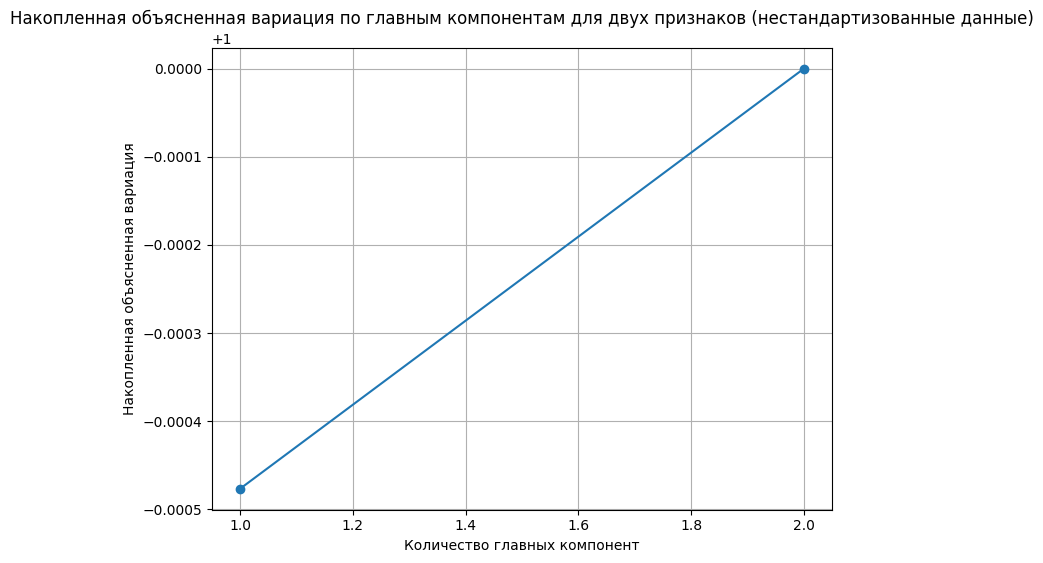

Компоненты PCA для двух признаков (нестандартизованные данные):
[[ 0.00383396  0.99999265]
 [ 0.99999265 -0.00383396]]


In [16]:
# Выбираем два признака для анализа
selected_features_two = ['sqft_living', 'sqft_lot']

# Извлекаем данные по этим признакам (без стандартизации)
data_selected_two_raw = kc_house_data[selected_features_two]

# Убираем строки с пропущенными значениями
data_selected_two_raw = data_selected_two_raw.dropna()

# Применяем PCA для этих двух признаков (без стандартизации)
pca_two_raw = PCA()
pca_two_raw.fit(data_selected_two_raw)

# Выводим вклад каждого компонента в объяснение вариации
print("Вклад каждого компонента в объяснение вариации для двух признаков (нестандартизованные данные):")
print(pca_two_raw.explained_variance_ratio_)

# Накопленная объясненная вариация
cumulative_variance_two_raw = np.cumsum(pca_two_raw.explained_variance_ratio_)

# Строим график накопленной объясненной вариации для двух признаков (нестандартизованные данные)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance_two_raw) + 1), cumulative_variance_two_raw, marker='o')
plt.title('Накопленная объясненная вариация по главным компонентам для двух признаков (нестандартизованные данные)')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объясненная вариация')
plt.grid(True)
plt.show()

# Выводим компоненты PCA для интерпретации
print("Компоненты PCA для двух признаков (нестандартизованные данные):")
print(pca_two_raw.components_)


**PCA для всего набора данных (нестандартизованные данные)**

Вклад каждого компонента в объяснение вариации для всего набора данных (нестандартизованные данные):
[9.99999983e-01 1.62863550e-08 2.55589822e-10 3.42980525e-11
 1.07394824e-13 3.18638944e-14 2.01766879e-14 1.77905725e-14
 3.07067017e-16 6.87101893e-17 6.93602247e-20 5.50701820e-20
 4.72198712e-20 4.10455319e-20 2.55779674e-20 1.50403427e-20
 1.80108322e-21 1.25719345e-21 7.09085572e-22 0.00000000e+00]


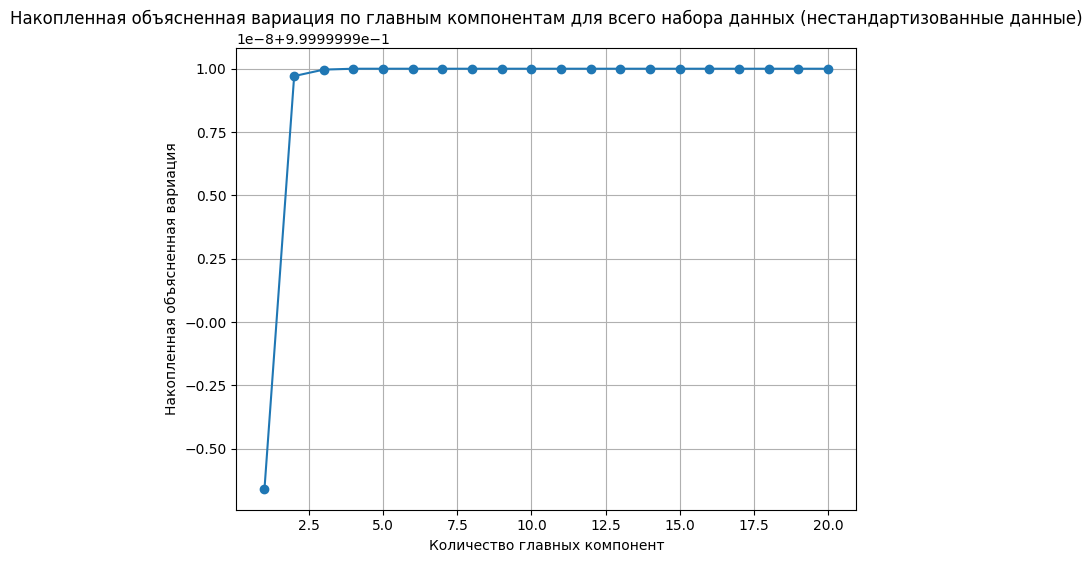

Компоненты PCA для всего набора данных (нестандартизованные данные):
[[ 1.00000000e+00 -2.13930752e-06  4.15883889e-13  1.38158511e-12
  -3.91370638e-09 -1.90227195e-06  3.47755604e-12 -8.18411440e-14
   3.08820816e-12 -5.38015358e-12  3.32236935e-12 -3.12117814e-09
  -7.92528238e-10  2.18318432e-10 -2.36086199e-09 -1.52975035e-10
  -9.10859180e-14  1.01823868e-12 -6.91214174e-10 -1.31746062e-06]
 [ 2.16621428e-06  9.99928251e-01  7.81402716e-07  1.10220207e-06
   1.75659526e-03  1.00278426e-02  3.78182603e-07  6.27752315e-08
   8.30001642e-07  6.37188314e-08  2.13816809e-06  1.36627771e-03
   3.90317551e-04  4.35835283e-06  1.38042317e-04 -7.80599122e-06
   1.15816023e-07  8.57632572e-09  1.09330243e-03  6.05106512e-03]
 [ 2.27897676e-06 -1.17166433e-02  9.70782260e-08  7.69569089e-07
   2.43107872e-03  8.70760663e-01 -3.36964680e-07  1.15033135e-09
   7.38079956e-07 -2.09757356e-07  1.60343616e-06  2.56551653e-03
  -1.34437807e-04  3.85641758e-05 -5.19368733e-05 -1.63828955e-04
  -3.

In [17]:
# Извлекаем все числовые признаки (без стандартизации)
data_numeric_raw = kc_house_data.select_dtypes(include=[np.number])

# Убираем строки с пропущенными значениями
data_numeric_raw = data_numeric_raw.dropna()

# Применяем PCA для всего набора данных (без стандартизации)
pca_full_raw = PCA()
pca_full_raw.fit(data_numeric_raw)

# Выводим вклад каждого компонента в объяснение вариации
print("Вклад каждого компонента в объяснение вариации для всего набора данных (нестандартизованные данные):")
print(pca_full_raw.explained_variance_ratio_)

# Накопленная объясненная вариация
cumulative_variance_full_raw = np.cumsum(pca_full_raw.explained_variance_ratio_)

# Строим график накопленной объясненной вариации для всего набора данных (нестандартизация)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance_full_raw) + 1), cumulative_variance_full_raw, marker='o')
plt.title('Накопленная объясненная вариация по главным компонентам для всего набора данных (нестандартизованные данные)')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объясненная вариация')
plt.grid(True)
plt.show()

# Выводим компоненты PCA для интерпретации
print("Компоненты PCA для всего набора данных (нестандартизованные данные):")
print(pca_full_raw.components_)


##Сравнение с результатами на стандартизованных данных:

После выполнения PCA для нестандартизованных данных мы сравним следующие результаты с теми, что были получены на стандартизованных данных:

* Вклад каждого компонента в объяснение вариации.

* График накопленной объясненной вариации.

* Главные компоненты (PCA components) для интерпретации.

**Ожидаемые результаты:**

1. На стандартизованных данных компоненты будут иметь одинаковый масштаб, что позволит более объективно оценивать важность каждого признака.

2. На нестандартизованных данных признаки с большим масштабом (например, площадь в квадратных футах) могут доминировать в первых компонентах, что может повлиять на интерпретацию.

3. Сравнение:

* Если результаты для нестандартизованных данных значительно отличаются от результатов для стандартизованных данных, это будет означать, что масштаб признаков играет важную роль в анализе главных компонент.
